**Fundamentos de mineração de dados e ciência de dados**

Processamento de dados e Análise exploratória II - 15/10

Exercícios:

Considere o conjunto de dados sobre o molusco Abalone, que pode ser encontrado
na página: https://archive.ics.uci.edu/dataset/1/abalone.

1 - Escolher uma variável quantitativa e uma qualitativa e caracterizar com moda,
mediana e os quartis, além de média e variância.

2 - Representar a variável escolhida com um diagrama de caixa.

3 - Comparar o diagrama de caixa à distribuição dessa variável com um histograma
de frequência. Verificar o comportamento do histograma com diferentes tamanhos
para os bins.

4 - Escolher 2 variáveis qualitativas e fazer a tabela de contingência para seus
valores.

5 - Criar um gráfico que demonstre ambas as variáveis juntas.

6 - Escolher 2 variáveis quantitativas e criar um gráfico que as relacione.

7- Calcular a correlação entre essas variáveis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"
colunas = ["Sex", "Length", "Diameter", "Height", "WholeWeight", "ShuckedWeight", "VisceraWeight", "ShellWeight", "Rings"]

df = pd.read_csv(url, header=None, names=colunas)
df.head()


,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


2. Escolher uma variável quantitativa e uma qualitativa

Quantitativa: Length

Qualitativa: Sex

In [2]:
# Estatísticas descritivas da variável quantitativa
length = df["Length"]
print("Moda:", length.mode()[0])
print("Mediana:", length.median())
print("Quartis:\n", length.quantile([0.25, 0.5, 0.75]))
print("Média:", length.mean())
print("Variância:", length.var())


Moda: 0.55
Mediana: 0.545
Quartis:
 0.25    0.450
0.50    0.545
0.75    0.615
Name: Length, dtype: float64
Média: 0.5239920995930094
Variância: 0.014422307648296695


3. Diagrama de caixa (Boxplot)

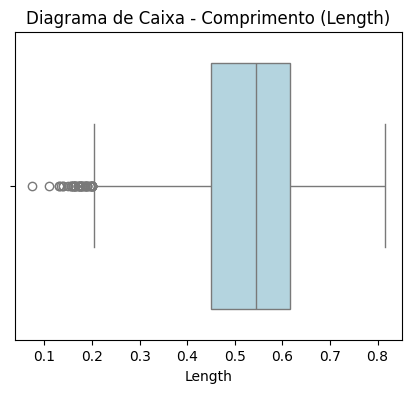

In [3]:
plt.figure(figsize=(5,4))
sns.boxplot(x=length, color="lightblue")
plt.title("Diagrama de Caixa - Comprimento (Length)")
plt.show()


4. Comparar com histograma de frequência

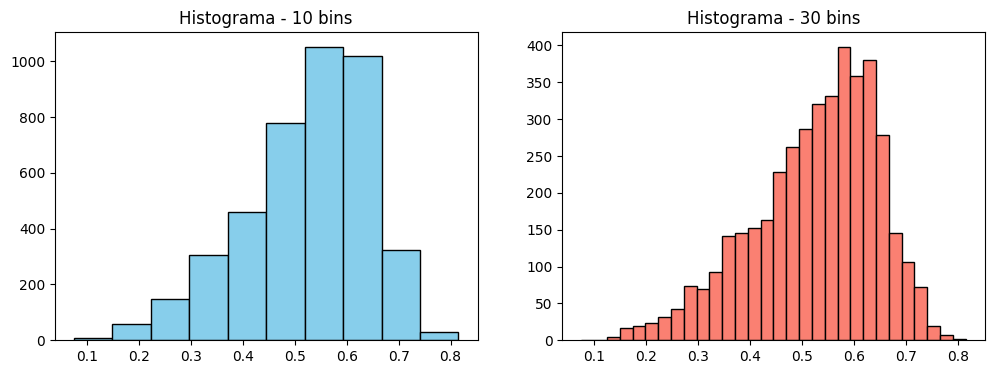

In [4]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(length, bins=10, color="skyblue", edgecolor="black")
plt.title("Histograma - 10 bins")

plt.subplot(1,2,2)
plt.hist(length, bins=30, color="salmon", edgecolor="black")
plt.title("Histograma - 30 bins")

plt.show()


5. Duas variáveis qualitativas e tabela de contingência

Variáveis: Sex e faixa etária aproximada (criada a partir de Rings).

In [5]:
df["AgeGroup"] = pd.cut(df["Rings"], bins=[0,8,12,30], labels=["Jovem","Adulto","Idoso"])
tabela = pd.crosstab(df["Sex"], df["AgeGroup"])
print(tabela)


AgeGroup  Jovem  Adulto  Idoso
Sex                           
F           186     814    307
I           922     348     72
M           299     915    314


Gráfico correspondente:

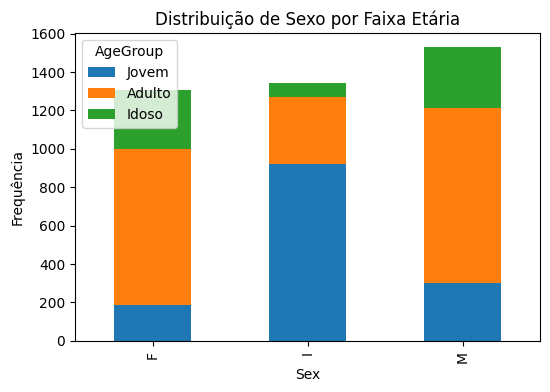

In [6]:
tabela.plot(kind="bar", stacked=True, figsize=(6,4))
plt.title("Distribuição de Sexo por Faixa Etária")
plt.ylabel("Frequência")
plt.show()


6. Duas variáveis quantitativas

Escolher: Length e WholeWeight

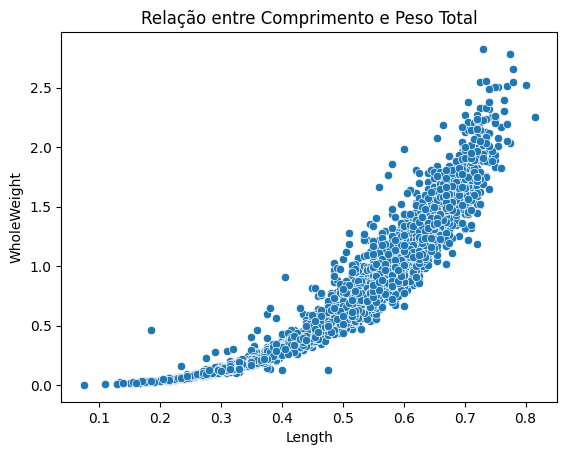

In [7]:
sns.scatterplot(x="Length", y="WholeWeight", data=df)
plt.title("Relação entre Comprimento e Peso Total")
plt.show()


7. Correlação

In [8]:
corr = df["Length"].corr(df["WholeWeight"])
print(f"Correlação entre Length e WholeWeight: {corr:.3f}")


Correlação entre Length e WholeWeight: 0.925
